# Objetivo del proyecto

 El objetivo es tratar de identificar grupos de pasajeros que tengan características similares con el fin de dirigirse a diferentes segmentos para distintos tipos de ofertas de millas.

 Para lo cual se debe probar con los diferentes metodos y variables para encontrar el mejor modelo, con su respectiva justificacion y reporte ejecutivo.

---


## Descripción de los datos

El archivo EastWestAirlines contiene la información del programa de viajero frecuente de los pasajeros de una aerolínea. Para cada pasajero los datos incluyen información del historial de millas

Para cada pasajero, los datos incluyen información sobre su historial de millas y sobre las diferentes formas en que acumularon o gastaron millas en el último año. El objetivo es tratar de identificar grupos de pasajeros que tengan características similares con el fin de dirigirse a diferentes segmentos para distintos tipos de ofertas de millas.

ID# --Unique ID

Balance--Number of miles eligible for award travel

Qual_mile--Number of miles counted as qualifying for Topflight status

cc1_miles -- Number of miles earned with freq. flyer credit card in the past 12 months:

cc2_miles -- Number of miles earned with Rewards credit card in the past 12 months:

cc3_miles -- Number of miles earned with Small Business credit card in the past 12 months:

1 = under 5,000

2 = 5,000 - 10,000

3 = 10,001 - 25,000

4 = 25,001 - 50,000

5 = over 50,000

Bonus_miles--Number of miles earned from non-flight bonus transactions in the past 12 months

Bonus_trans--Number of non-flight bonus transactions in the past 12 months

Flight_miles_12mo--Number of flight miles in the past 12 months

Flight_trans_12--Number of flight transactions in the past 12 months

Days_since_enrolled--Number of days since enrolled in flier program

Award?--whether that person had award flight (free flight) or not


# 0 - Importamos las librerías necesarias

In [37]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN # Importamos los 3 modelos de clusterización trabajados para esta campaña de mercadeo.
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1 - Cargamos los datos

In [11]:
dataset = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/No supervisado/Workshops/Workshop 2 - Airline /EastWestAirlines.xlsx')
dataset

,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0


# 1.2 - Exploramos los datos

In [12]:
dataset.info()
# Encontramos en todas las columnas datos de tipo non-null. Esto quiere decir que no tenemos casillas vacías

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID                 3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award              3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [13]:
dataset.describe()

,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


# 1.2 - Tratamos las casillas vacías

In [ ]:
# Verificamos que no tengamos filas vacías
dataset.isnull().sum()
# Encontramos 24 filas vacías en la columna de 'Income', les asignaremos 0 para no recurrir a eliminarlas apresuradamente. El resto del dataset contiene datos.

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


# 1.3 - Exploración visual de los datos

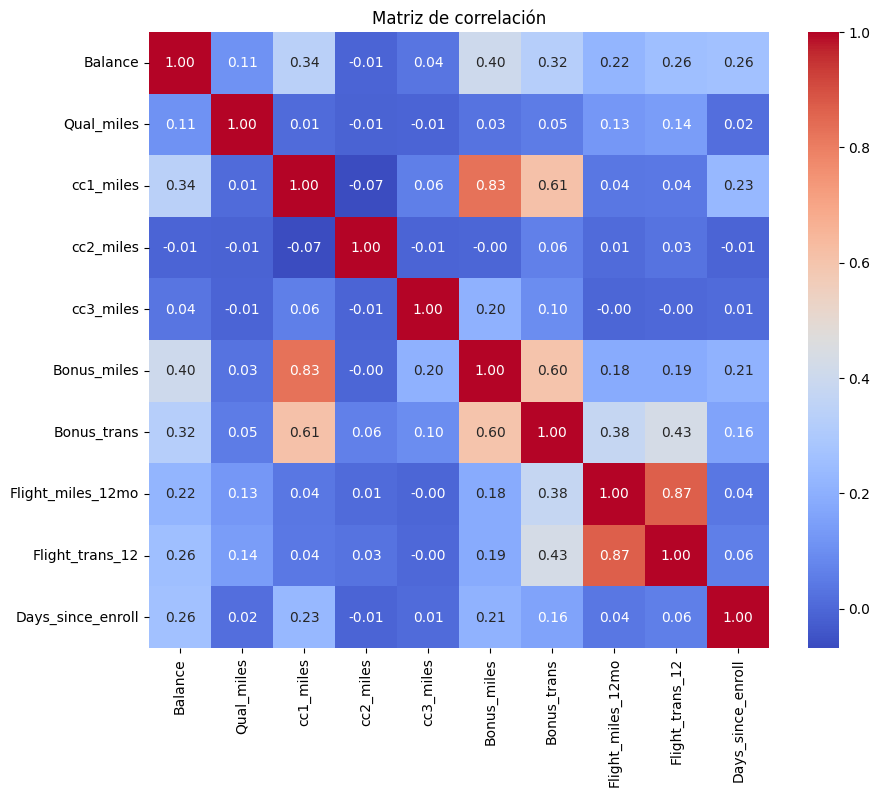

In [21]:
cols = ['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll']

# Creamos la matriz de correlación:
matriz_corr = dataset[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

## Correlación alta: cc1_miles y Bonus_miles (0.83).

## Correlación alta: Flight_miles_12mo y Flight_trans_12 (0.87).

## Bonus_trans - cc1_miles: 0.61 (moderada-alta).

## Bonus_trans - Bonus_miles: 0.60 (moderada-alta).

## Bonus_trans - Flight_trans_12: 0.43 (moderada).

## **Confirma grupo redundante:** cc1_miles, Bonus_miles, Bonus_trans. Las tres miden actividad de acumulación similar.

## **Segundo grupo redundante sigue:** Flight_miles_12mo, Flight_trans_12 (0.87).

## Resto de variables: correlación baja o nula.

## Aplicaremos PCA (Análisis de componentes principales) como técnica que nos permitirá reducir las dimensiones del dataset. Combinando así variables 'correlacionadas' en nuevos 'componentes'.

## Cada componente es una combinación lineal de las variables originales del dataset.

## De esta manera eliminamos la redundancia de algunas variables, sin perder tampoco información relevante.

## Requerimos escalar datos antes de aplicar PCA.

# 1.4 Revisamos outliers

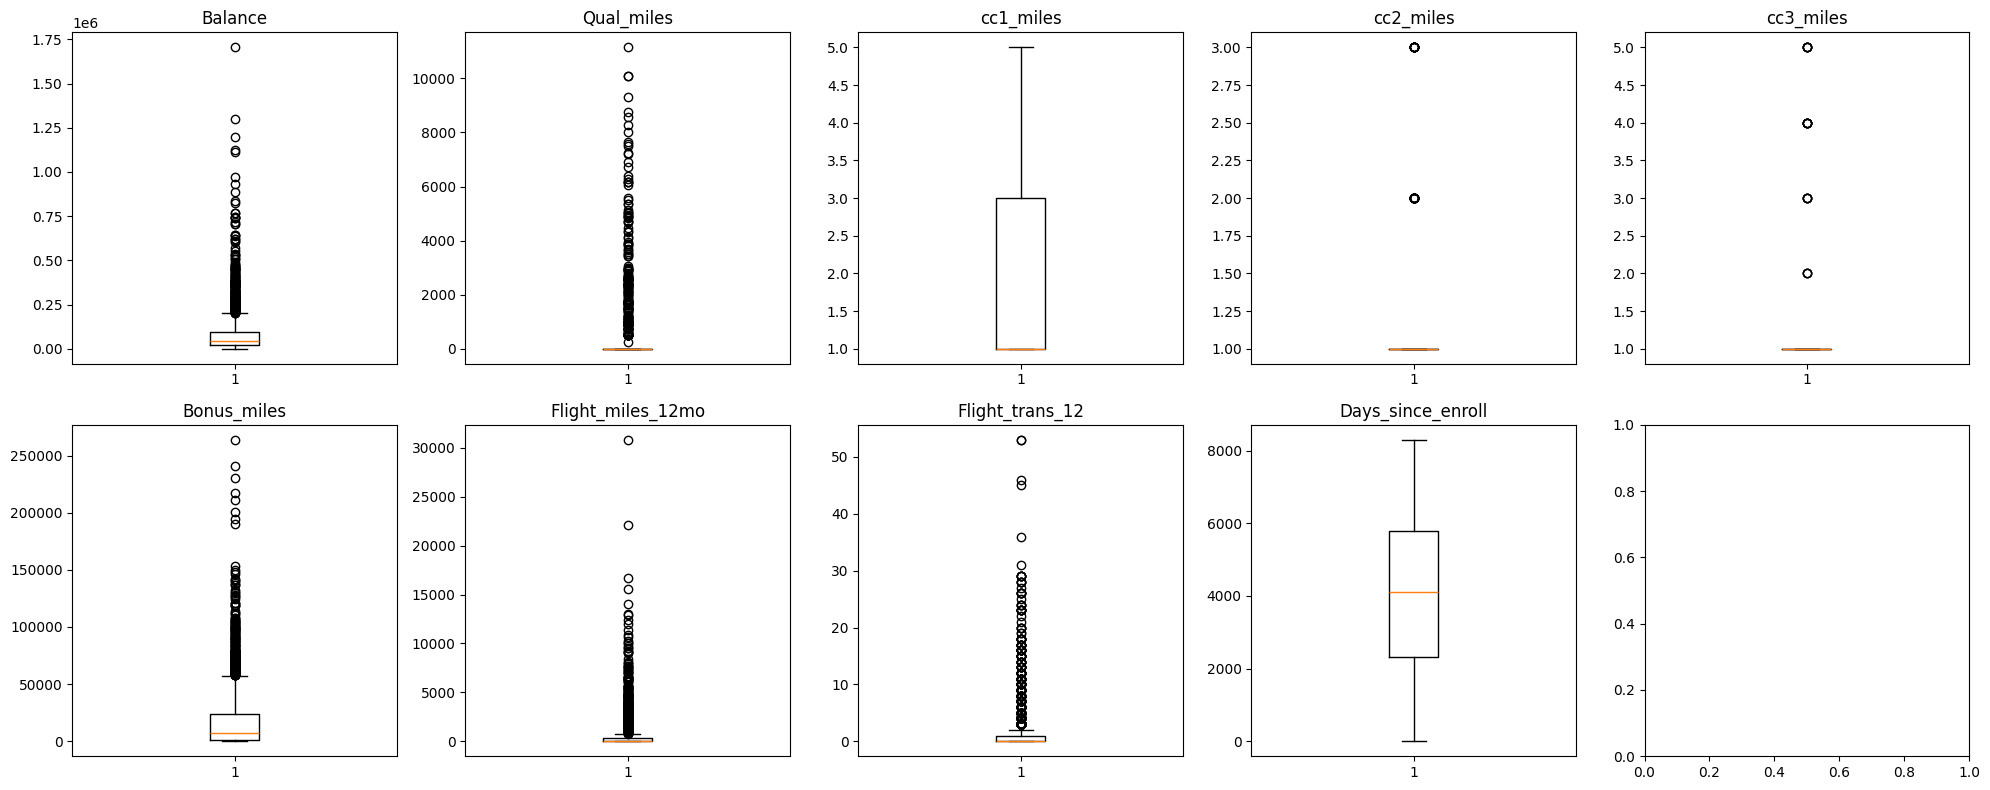

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(dataset[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Detectamos outliers usando IQR (Rango intercuartílico)

In [18]:
# Detección con IQR
for col in cols:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = dataset[(dataset[col] < lower) | (dataset[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

Balance: 266 outliers
Qual_miles: 226 outliers
cc1_miles: 0 outliers
cc2_miles: 43 outliers
cc3_miles: 18 outliers
Bonus_miles: 280 outliers
Flight_miles_12mo: 569 outliers
Flight_trans_12: 565 outliers
Days_since_enroll: 0 outliers


### La mayoría de outliers los encontramos en variables como de gasto / vuelo

**Outliers en Balance, Qual_miles, Bonus_miles:**

Reflejan comportamiento heterogéneo entre pasajeros.

Algunos acumulan millas activamente, otros poco.

Son clientes de alto valor real.

No representan errores de captura de datos.

**Outliers en Flight_miles_12mo, Flight_trans_12:**

Mayoría no realizó vuelos ese año.

Minoría sí vuela con frecuencia significativa.

Esa diferencia genera sesgo hacia cero.

Distingue viajeros activos de programa inactivo.

**Outliers en cc2_miles, cc3_miles:**

Poca variabilidad, casi todos valor mínimo.

Pocos casos usan esas tarjetas específicas.

Aportan señal limitada al análisis.

# 1.5 - Escalamos los datos

El dataset presenta outliers legítimos y relevantes. StandardScaler usa media y desviación estándar. Ambas medidas son sensibles a extremos. Outliers distorsionarían la escala resultante.

**RobustScaler** usa mediana y rango intercuartílico. Estas medidas resisten valores atípicos extremos. Preserva la información sin distorsionar distancias.

Resultado: clustering más representativo de segmentos reales.

In [22]:
cols = ['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll']


X = dataset[cols].copy()

# transformación log (maneja ceros y sesgo)
X_log = np.log1p(X)

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_log)

X_scaled = pd.DataFrame(X_scaled, columns=cols)

# 1.6 - PCA

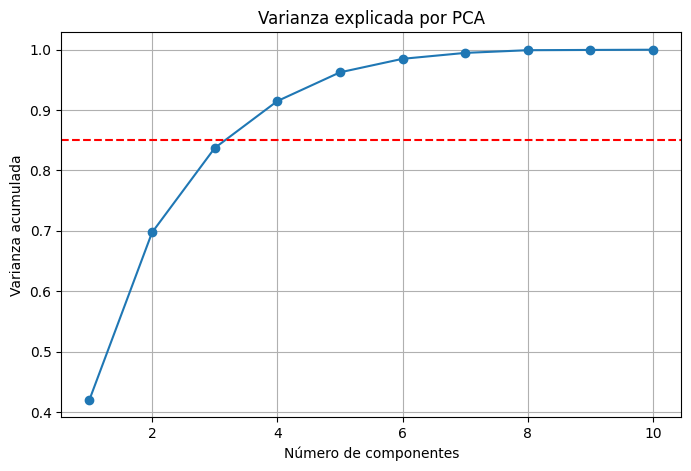

[4.20222515e-01 2.77128173e-01 1.39815210e-01 7.77577888e-02
 4.76124883e-02 2.24037747e-02 9.80204262e-03 4.47404764e-03
 4.23637873e-04 3.60321649e-04]
[0.42022252 0.69735069 0.8371659  0.91492369 0.96253618 0.98493995
 0.99474199 0.99921604 0.99963968 1.        ]


In [24]:
pca = PCA()
pca.fit(X_scaled)

# varianza explicada acumulada
var_exp = pca.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(var_acum)+1), var_acum, marker='o')
plt.axhline(y=0.85, color='r', linestyle='--')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('Varianza explicada por PCA')
plt.grid()
plt.show()

print(var_exp)
print(var_acum)

## Revisando el gráfico se hace busqueda del codo. Eligimos n_componentes donde acumulando ~85-90%.

## Vemos que con 4 componentes superamos casi el 91% de varianza acumulada. Usaremos entonces a partir de ahora solo 4 componentes para hacer la clusterización

## Esto nos sirve para clusterizar ahora sobre 4 columnas independientes entre sí, en lugar de hacerlo con 10 correlacionadas. Conservando en estas 4, cerca del 91% de la información original

# 1.7 - Elegimos variables para clusterización

In [27]:
pca_final = PCA(n_components=4)
X_pca = pca_final.fit_transform(X_scaled)

X_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4'])
# 'X_pca' será pues el dataset final para los modelos de clusterización

# 2 - Método del codo (K-Means)

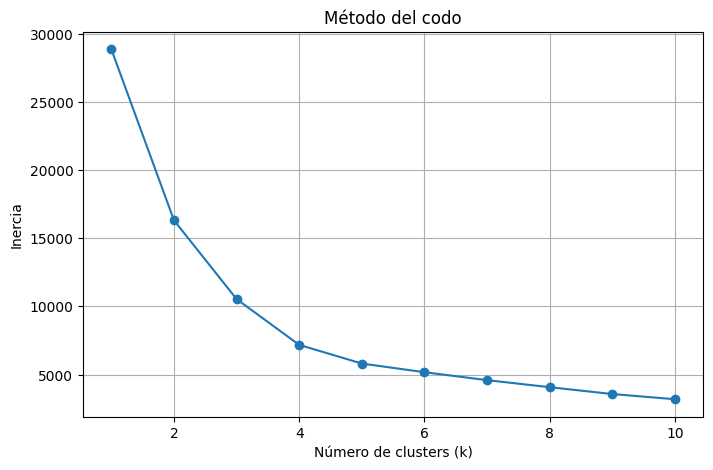

In [28]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.grid()
plt.show()
# Obtenemos el codo cerca de k = 4

In [29]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_pca) # Para comparación posterior.

# 2.2 - Gráfico k-distance (DBSCAN, eps)

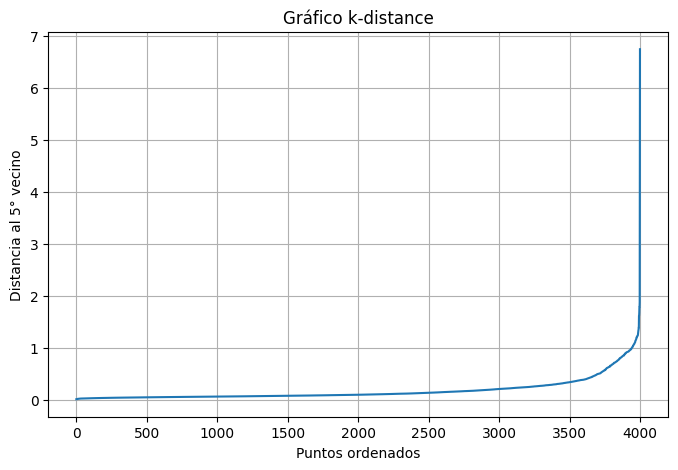

In [31]:
min_samples = 5  # regla general: 2 * n_dimensiones (4*2=8), pero 5 es común

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

# ordena distancias al k-ésimo vecino
distances = np.sort(distances[:, min_samples-1])

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel('Puntos ordenados')
plt.ylabel(f'Distancia al {min_samples}° vecino')
plt.title('Gráfico k-distance')
plt.grid()
plt.show()
# Codo apróximado entre 0.3 y 0.5, usaremos eps = 0.4 como punto inicial

In [32]:
dbscan = DBSCAN(eps=0.4, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_pca) # Para comparación posterior.

n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)

print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos de ruido: {n_noise}")

# 5 clusters = ~7.6% ruido. Razonable.

Clusters encontrados: 5
Puntos de ruido: 305


# 2.3 - Dendograma (HC / Hierarchical Clustering)

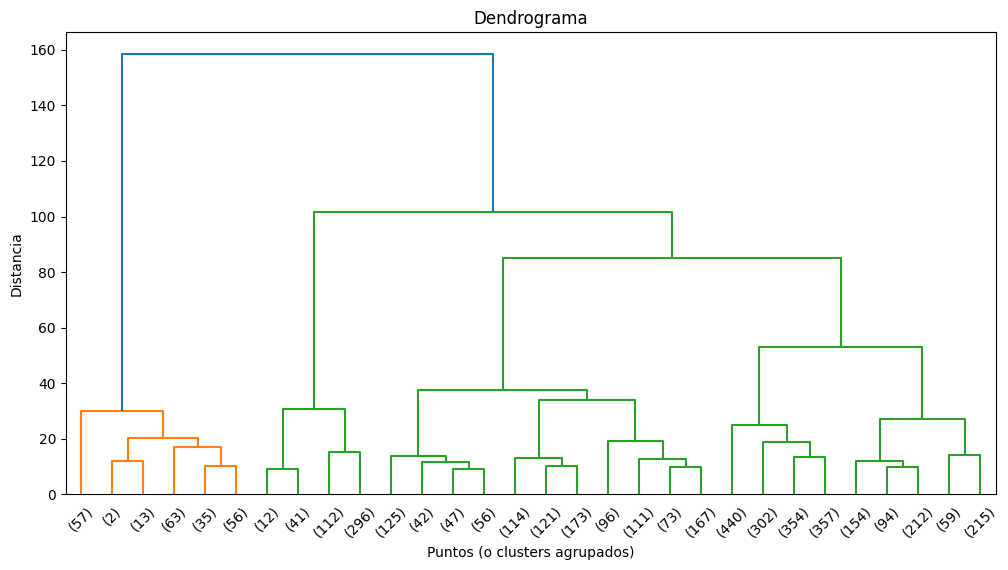

In [33]:
Z = linkage(X_pca, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.xlabel('Puntos (o clusters agrupados)')
plt.ylabel('Distancia')
plt.title('Dendrograma')
plt.show()

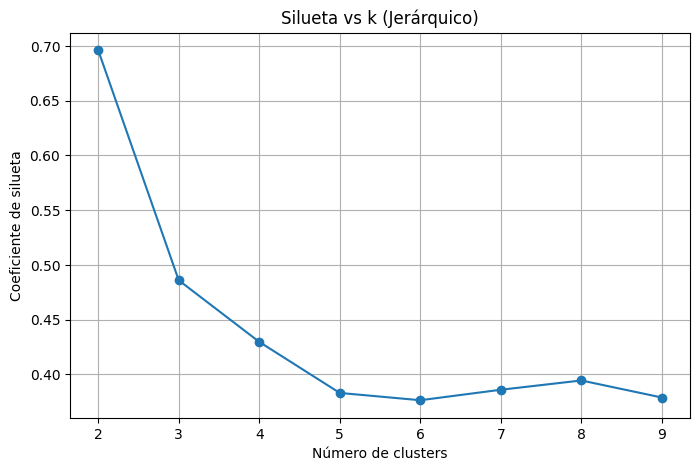

[np.float64(0.6960483288153123), np.float64(0.48599372171801186), np.float64(0.4297506069914644), np.float64(0.3831328341823923), np.float64(0.3764840898227853), np.float64(0.3860479831987359), np.float64(0.3945159796438625), np.float64(0.3789603826095959)]


In [34]:
silueta = []
n_cluster = range(2, 10)

for i in n_cluster:
    jerarquico = AgglomerativeClustering(n_clusters=i)
    jerarquico.fit(X_pca)
    score = silhouette_score(X_pca, jerarquico.labels_)
    silueta.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list(n_cluster), silueta, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Coeficiente de silueta')
plt.title('Silueta vs k (Jerárquico)')
plt.grid()
plt.show()

print(silueta)

# Vemos fuerte coeficiente de la silueta muy por encima de 0.5 con 2 clusteres. Obteniendo así una silueta de 0.70

In [35]:
jerarquico_final = AgglomerativeClustering(n_clusters=2)
labels_hierarchical = jerarquico_final.fit_predict(X_pca) # Para comparación posterior.

# 3 - Evaluación: Silueta + Davies-Bouldin

Davies-Bouldin mide calidad de clustering. Compara dispersión interna con separación entre clusters.

Valores bajos indican clusters compactos y bien separados.

Lo usamos junto a silueta, perspectiva complementaria.

Silueta evalúa por punto individual, cohesión-separación. Davies-Bouldin evalúa por cluster completo, promedio global.

Juntos dan visión más robusta antes de elegir modelo.

Especialmente útil comparando modelos con distinto número de clusters.

In [38]:
modelos = {
    'K-Means': labels_kmeans,
    'DBSCAN': labels_dbscan,
    'Jerárquico': labels_hierarchical
}

resultados = []

for nombre, labels in modelos.items():
    # DBSCAN: excluye ruido (-1) del cálculo
    if -1 in labels:
        mask = labels != -1
        X_eval = X_pca[mask]
        labels_eval = labels[mask]
    else:
        X_eval = X_pca
        labels_eval = labels

    sil = silhouette_score(X_eval, labels_eval)
    db = davies_bouldin_score(X_eval, labels_eval)
    n_clusters = len(set(labels_eval))

    resultados.append({
        'Modelo': nombre,
        'N_clusters': n_clusters,
        'Silueta': round(sil, 3),
        'Davies-Bouldin': round(db, 3)
    })

resultados_df = pd.DataFrame(resultados)
print(resultados_df)

       Modelo  N_clusters  Silueta  Davies-Bouldin
0     K-Means           4    0.426           0.811
1      DBSCAN           5    0.375           0.791
2  Jerárquico           2    0.696           0.514


# 3.2 - Elegimos modelo final

Jerárquico gana en ambas métricas.

Silueta más alta (0.696), Davies-Bouldin más bajo (0.514).

K-Means y DBSCAN quedan cerca entre sí.

**Interpretación:**

Jerárquico encuentra la separación más clara.

Pero solo 2 clusters, segmentación gruesa.

K-Means (4) y DBSCAN (5) dan más granularidad.

Con menor calidad estadística, pero más accionable.

**Recomendación:**

Elegir Jerárquico como modelo principal, mejor métrica.

Pero conservar K-Means como complemento, más segmentos accionables.

# 3.3 - Análisis de clústeres (HC y K-Means)

In [40]:
# agregamos labels al dataframe original
df_analysis = dataset[cols].copy()
df_analysis['Cluster_Jerarquico'] = labels_hierarchical
df_analysis['Cluster_KMeans'] = labels_kmeans

# medias por variable, por cluster
resumen_jerarquico = df_analysis.groupby('Cluster_Jerarquico')[cols].mean().round(1)
resumen_kmeans = df_analysis.groupby('Cluster_KMeans')[cols].mean().round(1)

print("=== Jerárquico (2 clusters) ===")
print(resumen_jerarquico)

print("\n=== K-Means (4 clusters) ===")
print(resumen_kmeans)

# tamaño de cada cluster
print("\nTamaño Jerárquico:")
print(df_analysis['Cluster_Jerarquico'].value_counts())

print("\nTamaño K-Means:")
print(df_analysis['Cluster_KMeans'].value_counts())

=== Jerárquico (2 clusters) ===
                     Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
Cluster_Jerarquico                                                          
0                    70040.4         0.0        2.1        1.0        1.0   
1                   133049.7      2550.1        2.2        1.0        1.0   

                    Bonus_miles  Bonus_trans  Flight_miles_12mo  \
Cluster_Jerarquico                                                
0                       16724.3         11.4              384.6   
1                       24166.0         15.6             1720.1   

                    Flight_trans_12  Days_since_enroll  
Cluster_Jerarquico                                      
0                               1.1             4104.3  
1                               5.2             4356.7  

=== K-Means (4 clusters) ===
                 Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
Cluster_KMeans                                             

# Análisis e interpretación de los clústeres

**Jerárquico / HC (2 clusters):**

*Cluster* *0* (n=3773): balance bajo, sin Qual_miles, vuelo mínimo.

*Perfil*: clientes masivos, poco comprometidos, sin status.

*Cluster* *1* (n=226): balance alto, Qual_miles>0, vuelo alto.

*Perfil*: clientes élite, status Topflight, alto valor.

**Segmentación macro: masa vs élite.**

**K-Means (4 clusters):**

*Cluster 0* (n=1916): balance medio, cero vuelos, bonus alto.

*Perfil*: acumulan millas sin volar (tarjetas, promociones).

*Cluster 1* (n=782): balance bajo, actividad casi nula.

*Perfil*: clientes inactivos/dormidos.

*Cluster 2* (n=226): balance alto, Qual_miles, vuelo alto.

*Perfil*: élite (coincide con cluster 1 de Jerárquico).

*Cluster 3* (n=1075): balance alto, sin Qual_miles, vuelo activo.

*Perfil*: viajeros frecuentes no-élite, alto potencial.

**Insight clave:**

K-Means separa el grupo masivo de Jerárquico en 3.

Distingue: acumuladores pasivos, inactivos, viajeros activos.

Útil para ofertas diferenciadas por comportamiento real.

# 4 - Conclusiones y reporte ejecutivo

## Se aplicó clustering a la base EastWestAirlines (~4000 pasajeros), usando PCA (Análisis de Componentes Principales, con 4 componentes y 91% varianza) sobre variables de balance, millas y actividad de vuelo.

## Se compararon 3 modelos: K-Means, DBSCAN y Jerárquico, todos fueron evaluados con coeficiente de la silueta y Davies-Bouldin.

## Modelo Jerárquico (2 clusters) obtuvo mejor desempeño estadístico (silueta 0.696, DB 0.514), revelando una división macro: clientes masivos de bajo compromiso (94%) vs clientes 'élite' de alto valor (6%).

## Modelo K-Means (4 clusters) ofrece mayor granularidad táctica, distinguiendo dentro del segmento masivo tres subgrupos: acumuladores pasivos, clientes inactivos, y viajeros frecuentes no-élite.

## Modelo DBSCAN identificó 5 clusters con 305 puntos de ruido (7.6%), útil para detectar comportamientos atípicos o casos fronterizos no capturados por los otros modelos implementados.

# **Conclusión**:

## La combinación de modelos aporta valor complementario. El Clustering Jerárquico define la estrategia macro (retención élite vs activación masiva). K-Means permitió plantear campañas segmentadas específicas por comportamiento de cliente, y DBSCAN como bien lo comentabamos previamente, nos permite identificar los comportamientos atípicos.

## Sin embargo, para este preciso caso, se sugiere utilizar el modelo de clusterización jerárquico (HC) ya que es el que mejores resultados nos ofrece en sus métricas de evaluación, acompañado de una buena interpretación clara en la separación de sub-grupos encontrados en el espectro total de viajeros que encontramos en la base de datos suministrada.

# **Recomendaciones de negocio:** Segmentar a los clientes según estas descripciones:

## Élite (Cluster 1/2): Programas de fidelización premium, como mejoras de experiencia por acumulación de millas o frecuencia de viajes (Por dar un ejemplo).

## Viajeros no-élite activos: Incentivos para alcanzar status 'Topflight'.

## Acumuladores pasivos: Ofertas para convertir millas en vuelos.

## Inactivos: Campañas de reactivación como millas por tiempo limitado o descuentos para vuelos en los que se tenga una baja demanda de asientos, solucionando una posible problemática, y retomando una venta que no se tenía pronosticada. Estrategía que a gran escala y con tiempo podría hacer que este perfil de viajero se convierta en uno de 'Acumulador Pasivo'.